#### Download datasets
##### download SberSQuAD

In [1]:
import pandas as pd
df1 = pd.read_json('./raw_datasets/sberquad/sberquad_train.json')
df2 = pd.read_json('./raw_datasets/sberquad/sberquad_test.json')
df3 = pd.read_json('./raw_datasets/sberquad/sberquad_valid.json')

sbersquad_df = pd.concat([df1, df2, df3], ignore_index=True)   
sbersquad_df['answer'] = sbersquad_df["answers"].apply(lambda x: x["text"][0])
sbersquad_df = sbersquad_df[["context", "question", "answer"]].copy()

no_answ_df = sbersquad_df[sbersquad_df["answer"]==''].copy()
no_answ_df = no_answ_df.drop_duplicates(subset="context", keep="first").copy()

sbersquad_df = sbersquad_df[sbersquad_df["answer"]!=''].copy()
sbersquad_df

,context,question,answer
0,В протерозойских отложениях органические остат...,чем представлены органические остатки?,известковыми выделениями сине-зелёных водорослей
1,В протерозойских отложениях органические остат...,что найдено в кремнистых сланцах железорудной ...,"нитевидные водоросли, грибные нити"
2,В протерозойских отложениях органические остат...,что встречается в протерозойских отложениях?,органические остатки
3,В протерозойских отложениях органические остат...,что относится к числу древнейших растительных ...,скопления графито-углистого вещества
4,В протерозойских отложениях органические остат...,как образовалось графито-углистое вещество?,в результате разложения Corycium enigmaticum
...,...,...,...
74295,Классическая трёхуровневая система накачки раб...,Где используется классическая трёхуровневая си...,в рубиновом лазере.
74296,Первая платёжная карта American Express появил...,какой инвестиционный банк входил в состав Amer...,Lehman Brothers
74297,Следующий альбом Heroes был во многом созвучен...,С каким альбомом был созвучен альбом Дэвида Бо...,Low
74298,"Одним из тех, на кого игра Данна произвела неи...",В каком техасском оркестре выступал гитарист Л...,Light Crust Doughboys


In [2]:
no_answ_df

,context,question,answer
45328,Многоклеточный организм — внесистематическая к...,У каких организмов отсутствуют настоящие диффе...,
45341,Акционерное общество открытого типа АКБ „Моско...,Когда была получена лицензия на осуществление ...,
45346,Однако не лишён этот язык и недостатков: так у...,"В какой среде рожденный, он стимулирует соотве...",
45355,Даже простая убеждённость в чём-либо на основе...,На основе чего простая убеждённость в чём-либо...,
45360,"Транспорт — густая сеть железных дорог, морско...",Какие украшения характерны для конька крыши фл...,
...,...,...,...
69239,В СССР серийно выпускались тепловозы ТЭ1 (1000...,Какая мощность была у серийно выпущенных тепло...,
69244,Мясо собаки являлось традиционным пищевым прод...,"Куда в Азии, согласно кулинарным традициям, по...",
69249,При написании Германии и этнографическо-геогра...,Каким является вопрос о роли личного опыта в о...,
69254,Банк ВТБ является головной структурой Группы В...,Где находятся дочерние и ассоциированные банки...,


##### Download WikiOmnia

In [3]:
from datasets import load_dataset

wo1_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_filtered/wikiomnia_ruT5_filtered_train.json"
    }
)["train"].to_pandas()

wo2_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruGPT3_filtered/wikiomnia_ruGPT_3_filtered_train.json"
    }
)["train"].to_pandas()

wo3_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_raw/wikiomnia_dev.json"
    }
)["train"].to_pandas()

wo4_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_raw/wikiomnia_test.json"
    }
)["train"].to_pandas()

c:\Users\Sergey\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Prepare main dataset

In [4]:
import re, pandas as pd
pd.reset_option("display.max_colwidth")

def repetition_score(text):
    text = re.sub(r'[^a-zа-яё0-9 ]', ' ', text.lower()).split()
    return len(set(text)) / len(text)

# ---- concat raw datasets ----
wo_df = pd.concat([wo1_df, wo2_df, wo3_df, wo4_df], ignore_index=True)   
wo_df = wo_df[["summary", "question", "answer",]].rename(
    columns={"summary": "context"}
)
full_df = pd.concat([wo_df, sbersquad_df], ignore_index=True)

# ---- drop deduplicates ----
full_df["answer_lower"] = full_df["answer"].str.lower()
full_df = full_df.drop_duplicates(subset="answer_lower", keep="first").copy()
full_df["question_lower"] = full_df["question"].str.lower()
full_df = full_df.drop_duplicates(subset="question_lower", keep="first").copy()
full_df = full_df.drop(columns=["answer_lower", "question_lower"]).copy()

# ---- drop short sentences ----
min_cont_len = 240
full_df = full_df[full_df["answer"].fillna("").str.len() > 45]
full_df = full_df[full_df["context"].str.len() > min_cont_len]
full_df = full_df[(full_df["answer"].str.len() / full_df["context"].str.len()) < 0.8]

# drop short sentences in no answer data
no_answ_df = no_answ_df[no_answ_df["context"].str.len() > min_cont_len]

# ---- drop context with formula like {...} ---- 
pattern = r"[{}]"
mask = full_df['context'].str.contains(pattern, regex=True, na=False)
full_df = full_df[~mask].copy()

# drop formula in no answer dataset
mask = no_answ_df['context'].str.contains(pattern, regex=True, na=False)
no_answ_df = no_answ_df[~mask].copy()

# ---- drop context with list of source ----
pattern = r"//[^//]+//"
mask = full_df['context'].str.contains(pattern, regex=True, na=False)
full_df = full_df[~mask].copy()

# drop context with list of source in no answer dataset
mask = no_answ_df['context'].str.contains(pattern, regex=True, na=False)
no_answ_df = no_answ_df[~mask].copy()

# ---- drop repetition text ---- 
threshold = 0.6
for col in ["context", "question", "answer"]:
    full_df = full_df[full_df[col].map(repetition_score) > threshold]

# drop repetition text in no answer dataset
no_answ_df = no_answ_df[no_answ_df['context'].map(repetition_score) > threshold]

full_df

,context,question,answer
8,Тиопентал натрия (лат. Thiopentalum-natrium) —...,Что такое тиопентал натрия?,средство для неингаляционного наркоза ультрако...
11,Алгоритмическая разрешимость — свойство формал...,Чем является вопрос о выводимости в формальной...,"частным, но вместе с тем важнейшим случаем бол..."
21,Пушечный двор (Москва) — центр пушечно-литейно...,Где существовали производства пушечно-литейног...,"во многих городах сторон (краях, странах) Русс..."
37,Не следует путать с предельной прибылью. Маржи...,Что такое маржинальная прибыль?,разница между выручкой от реализации и перемен...
71,Прое́зжая часть — элемент дороги или дорожного...,Что такое проезжая часть?,"элемент дороги или дорожного сооружения, предн..."
...,...,...,...
2845715,К обрабатывающей промышленности относятся пред...,Продуктами чего являются строительные материалы?,деревообработки и целлюлозно-бумажной промышле...
2845725,Через два столетия король франков Карл Великий...,Кто притязал именоваться наследниками Западной...,императоры основанной в 962 Священной Римской ...
2845729,Именной Указ Государя Императора издавался в д...,В каких случаях преимущественно Николай I при ...,когда к нему присоединялся председатель Госуда...
2845734,"Литва планировала перейти на евро в 2007 году,...",Из-за чего задержался переход на евро?,Из-за незначительного превышения Маастрихтских...


In [5]:
no_answ_df

,context,question,answer
45328,Многоклеточный организм — внесистематическая к...,У каких организмов отсутствуют настоящие диффе...,
45341,Акционерное общество открытого типа АКБ „Моско...,Когда была получена лицензия на осуществление ...,
45346,Однако не лишён этот язык и недостатков: так у...,"В какой среде рожденный, он стимулирует соотве...",
45355,Даже простая убеждённость в чём-либо на основе...,На основе чего простая убеждённость в чём-либо...,
45360,"Транспорт — густая сеть железных дорог, морско...",Какие украшения характерны для конька крыши фл...,
...,...,...,...
69234,На основе прежней конфедерации телеских племён...,Какой года был последним годом существования С...,
69244,Мясо собаки являлось традиционным пищевым прод...,"Куда в Азии, согласно кулинарным традициям, по...",
69249,При написании Германии и этнографическо-геогра...,Каким является вопрос о роли личного опыта в о...,
69254,Банк ВТБ является головной структурой Группы В...,Где находятся дочерние и ассоциированные банки...,


#### Check repetition score and length distribution

In [6]:
print('\nContext repetition score:\n', full_df['context'].map(repetition_score).describe())
print('\nAnswers length:\n', full_df["answer"].str.len().describe())


Context repetition score:
 count    64210.000000
mean         0.835548
std          0.080802
min          0.600386
25%          0.781250
50%          0.839286
75%          0.894737
max          1.000000
Name: context, dtype: float64

Answers length:
 count    64210.000000
mean        63.600607
std         17.959608
min         46.000000
25%         51.000000
50%         58.000000
75%         71.000000
max        258.000000
Name: answer, dtype: float64


In [7]:
from pathlib import Path
import sys

proj_root = Path("..").resolve()    # Path().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.append(str(proj_root))

#### Clean main dataset

In [8]:
pd.set_option("display.max_colwidth", None)
from qa_datasets.qa_cleaner import QACleaner
from tokenizer.bpe_tokenizer import BPETokenizer

bpe_tokenizer = BPETokenizer().from_file("../tokenizer/bpe_tokenizer_v2/tokenizer.json")
bpe_tokenizer.post_processor = None

cleaner = QACleaner(bpe_tokenizer)

full_df = cleaner.clean_df(full_df)
full_df

,context,question,answer,answer_len,context_len,instruction_type,instruction
0,"Комбинированный двигатель внутреннего сгорания (комбинированный ДВС) — двигатель внутреннего сгорания, представляющий собой комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор), в котором в осуществлении рабочего процесса участвуют обе машины.",Что представляет собой двигатель внутреннего сгорания?,"комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор)",31,64,default,Ответь используя только данный контекст.
1,"ОВРА — орган политического сыска в Королевстве Италия времен правления короля Виктора Эммануила III. Коммунисты и анархисты расшифровывали его название как итал. Organizzazione di Vigilanza e Repressione dell' Antifascismo — ""Организация выявления и подавления антифашизма"", в результате чего эту службу, особенно после 1945 года, многие источники стали называть ""Organizzazione di Vigilanza e Repressione dell' Antifascismo"".",Как коммунисты и анархисты расшифровывали название ОВРА?,как итал. Organizzazione di Vigilanza e Repressione dell' Antifascismo,33,121,default,Ответь используя только данный контекст.
2,"В легендариуме Дж. Р. Р. Толкина описано множество войн и сражений, происходивших в землях Амана, Белерианда, Нуменора и Средиземья. Они описаны в таких книгах, как ""Сильмариллион"", ""Хоббит"", ""Властелин колец"", ""Неоконченные сказания"" и других произведениях, изданных посмертно под редакцией Кристофера Толкина. Ниже приведён список битв вымышленного мира Средиземья в хронологическом порядке.",В каких книгах описаны войны и сражения?,"""Сильмариллион"", ""Хоббит"", ""Властелин колец"", ""Неоконченные сказания"" и других произведениях, изданных посмертно под редакцией Кристофера Толкина",38,100,default,Ответь используя только данный контекст.
3,"О полосе пропускания в цифровой технике см. Скорость передачи информации Полоса пропускания (прозрачности) — диапазон частот, в пределах которого амплитудно-частотная характеристика (АЧХ) акустического, радиотехнического, оптического или механического устройства достаточно равномерна для того, чтобы обеспечить передачу сигнала без существенного искажения его формы. Иногда вместо термина ""полоса пропускания"" используют термин ""эффективно передаваемая полоса частот""",Что такое полоса пропускания?,"диапазон частот, в пределах которого амплитудно-частотная характеристика (АЧХ) акустического, радиотехнического, оптического или механического устройства достаточно равномерна",38,95,default,Ответь используя только данный контекст.
4,"Войска радиационной, химической и биологической защиты — специальные войска, предназначенные для защиты вооружённых сил, населения и объектов тыла от воздействия радиационного, химического, биологического (РХБ) и других видов оружия массового поражения (ОМП), а также для ликвидации последствий применения ОМП и техногенных катастроф, как в военное, так и в мирное время.",Для чего предназначены специальные войска?,"для защиты вооружённых сил, населения и объектов тыла от воздействия радиационного, химического, биологического (РХБ) и других видов оружия массового поражения (ОМП)",34,74,default,Ответь используя только данный контекст.
...,...,...,...,...,...,...,...
55165,"К обрабатывающей промышленности относятся предприятия машиностроения, предприятия по производству чёрных и цветных металлов, проката, химических и нефтехимических продуктов, машин и оборудования, продуктов деревообработки и целлюлозно-бумажной промышленности, цемента и др. строительных материалов, продуктов лёгкой и пищевой промышленности, местная промышленность, а также предприятия по ремонту промышленных изделий (паровозоремонтная, локомотиворемонтная) и теплоэлектростанции, кинопромышленность (киноиндустрия).",Продуктами чего являются строительные материалы?,"К обрабатывающей промышленности относятся предприятия машиностроения, предприятия по производству чёрных и цветных металлов, проката, химических и нефтехимических продуктов, ма

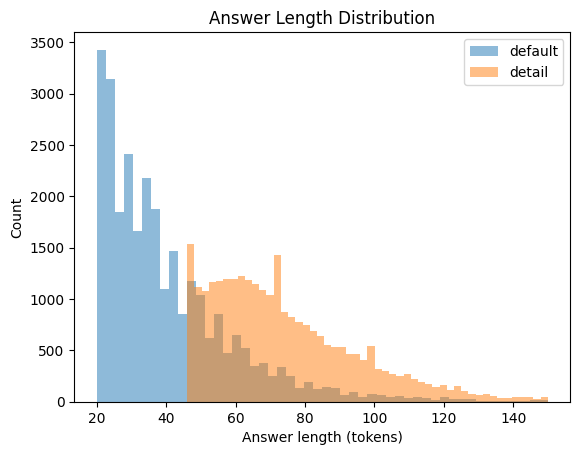

In [9]:
import matplotlib.pyplot as plt

def answer_len_distrib(df):
    default_answers_len = df.loc[
        df['instruction_type'] == 'default', 'answer'
    ].map(cleaner._encoded_text_len)

    detail_answers_len = df.loc[
        df['instruction_type'] == 'detail', 'answer'
    ].map(cleaner._encoded_text_len)

    plt.figure()
    plt.hist(default_answers_len, bins=50, alpha=0.5, label="default")
    plt.hist(detail_answers_len, bins=50, alpha=0.5, label="detail")

    plt.xlabel("Answer length (tokens)")
    plt.ylabel("Count")
    plt.title("Answer Length Distribution")
    plt.legend()
    plt.show()

answer_len_distrib(full_df)

# print('\nAnswers length:\n', full_df['answer'].map(cleaner._encoded_text_len).describe())

#### Clean no answers dataset 

In [10]:
from qa_instructions import pick_instruction
import numpy as np

# ---- remove accents and normalize ----
no_answ_df['context'] = no_answ_df['context'].map(cleaner.remove_accents).map(cleaner.normalize_text)   

# ---- length filter ----
no_answ_df["context_len"] = no_answ_df["context"].map(cleaner._encoded_text_len)
no_answ_df = no_answ_df[
    (no_answ_df["context_len"] > 150) & (no_answ_df["context_len"] < 300)
].copy()

# sample up to 3% no answers
n = int(0.03 * full_df.shape[0])
no_answ_df = no_answ_df.sample(n=min(n, len(no_answ_df)), random_state=42).copy()

# map instruction
no_answ_df["instruction_type"] = np.random.choice(
    ["default", "detail"],
    size=len(no_answ_df),
    p=[0.5, 0.5]    
)
no_answ_df["instruction"] = no_answ_df["instruction_type"].apply(pick_instruction)

no_answ_df

,context,question,answer,context_len,instruction_type,instruction
65365,"Ведущая отрасль сельского хозяйства — растениеводство. Выращивают пшеницу, ячмень, кукурузу (в центральных и южных областях страны), рис, картофель и сахарную свеклу, бобовые. Также овощи: помидоры, лук, перец, баклажаны. Оливки (ведущее место по выращиванию оливок в мире), цитрусовые и табак. На самом юге страны выращивают миндаль (ведущее место по экспорту в Западной Европе), финики и сахарный тростник (в Европе произрастают только в Испании), инжир, гранаты, хлопчатник. Виноградарство — на Средиземноморском побережье и в областях Кастилия-Ла-Манча, Эстремадура.",Какая часть посевных площадей в Испании отведена под овощи?,,159,detail,Дай детальный ответ только из этих документов.
62809,"Натаниэль Готорн и Эдгар По вошли в историю новеллистики как выдающиеся новаторы. Путём бесшовного сращения сказания и очерка Готорн создал аналог веверлеевских романов В. Скотта — поджанр исторического рассказа. За необычайными событиями новеллы у Готорна нередко проступает моральная притча. Интериоризация сюжета свойственна и произведениям Эдгара По: из сферы чистой фантастики удивительное перемещается в область психических феноменов. Излюбленные мотивы его новеллистики — двойничество ( Вильям Вильсон ), погребение заживо ( Падение дома Ашеров ), оживление мертвецов и переселение душ ( Лигейя ), совмещение хронотопов ( Повесть крутых гор ). Ему также принадлежит заслуга разработки новых жанровых подвидов — новеллы авантюрной ( Золотой жук ) и детективной (рассказы о сыщике Дюпене).",За какие разработки принадлежит заслуга Эдгару По?,,199,detail,Дай детальный ответ только из этих документов.
57602,"Деревянистые плодовые тела состоят из плотно переплетённых жёстких гиф, они имеют наибольшую прочность — разрушить их можно только пилой или топором. Пробковые, войлочные и кожистые менее прочны, их можно резать ножом. Пробковые плодовые тела упругие, состоят из беспорядочно переплетённых гиф, поэтому имеют одинаковую прочность во всех направлениях. Гифы войлочной мякоти образуют пучки волокон, которые можно разодрать в ватообразную массу, или трут. Сухой, предварительно обожжённый трут легко вспыхивает от искры и в старину широко применялся для добывания огня. Грибы с кожистой консистенцией обычно имеют тонкую мякоть, она эластична, не ломается при изгибе и обладает высокой прочностью.",Какие виды плодовых тел гриба однородны по прочности?,,176,detail,Дай детальный ответ только из этих документов.
58609,"Однако, несмотря на снижение популярности альтернативного рока, некоторые его исполнители сохранили популярность. Так, в начале 00-х постгранж по-прежнему оставался коммерчески жизнеспособным жанром, так такие коллективы, как Creed и Matchbox Twenty, стали одними из самых популярных рок-групп в Соединённых Штатах. В свою очередь, на фоне упадка популярности брит-попа, группа Radiohead достигла пика в своей музыкальной карьере — получив признание публики и очень высокие оценки критиков за альбом OK Computer (1997), а также последующие свои пластинки — Kid A (2000) и Amnesiac (2001), которые резко контрастировали с традиционализмом брит-попа. Radiohead, наряду с постбритпоп группами, такими как Travis и Coldplay, занимали ведущие позиции на британской рок-сцене в следующем десятилетии.",Из-за чего группа Radiohead достигла пика в своей музыкальной карьере?,,187,detail,Дай детальный ответ только из этих документов.
49238,"Первоначально Гермес — фаллическое божество, изображавшееся гермами. Согласно Геродоту, афиняне первыми из эллинов стали делать его изображение с напряженным членом, научившись этому у пеласгов, у которых было священное сказание. Герма представляла собой каменную колонну с вырезанной головой Гермеса и подчёркнутыми половыми органами. Устанавливались гермы на перекрёстках дорог и, наряду с сакральной функцией, служили дорожными указателями. В 415 до н. э. гермы были уничтожены. Во времена Рима они потеряли связь с фаллическим культом Гермеса и стали изготавлива

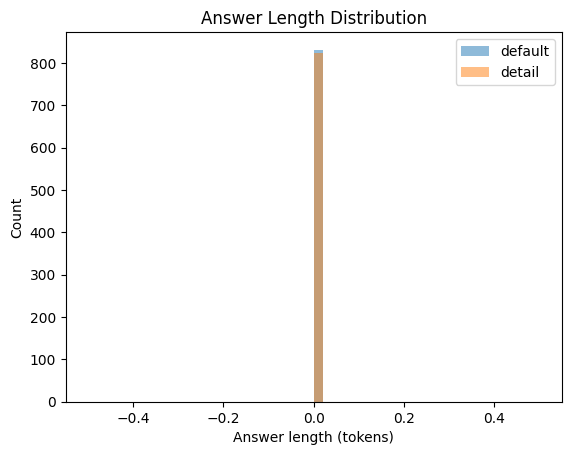

In [11]:
answer_len_distrib(no_answ_df)

#### Check instruction_type and tokens length distribution

In [12]:
print('Numbers of detail (TO DO):', int(cleaner.long_answ_ratio * full_df.shape[0]))
counts = full_df["instruction_type"].value_counts()
print(counts, '\ntotal =', counts.sum()) 
print('\nContext tokens length:\n', full_df["context"].map(cleaner._encoded_text_len).describe())
print('\nAnswers length:\n', full_df['answer'].map(cleaner._encoded_text_len).describe())

Numbers of detail (TO DO): 33102
instruction_type
default    28366
detail     26804
Name: count, dtype: int64 
total = 55170

Context tokens length:
 count    55170.000000
mean       156.023002
std        115.577087
min         31.000000
25%         79.000000
50%        121.000000
75%        192.000000
max        720.000000
Name: context, dtype: float64

Answers length:
 count    55170.000000
mean        56.596447
std         26.193971
min         20.000000
25%         34.000000
50%         54.000000
75%         72.000000
max        150.000000
Name: answer, dtype: float64


#### Check no_answ context length distribution

In [13]:
print('\nContext tokens length:\n', no_answ_df["context"].map(cleaner._encoded_text_len).describe())


Context tokens length:
 count    1655.000000
mean      195.758308
std        36.338937
min       151.000000
25%       167.000000
50%       186.000000
75%       218.000000
max       299.000000
Name: context, dtype: float64


#### Concat to final dataset

In [14]:
# keep only necessary columns
columns = ['context', 'question', 'answer', 'instruction']
no_answ_df = no_answ_df[columns].copy()
full_df = full_df[columns].copy()
full_df = pd.concat([full_df, no_answ_df], ignore_index=True)  
full_df

,context,question,answer,instruction
0,"Комбинированный двигатель внутреннего сгорания (комбинированный ДВС) — двигатель внутреннего сгорания, представляющий собой комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор), в котором в осуществлении рабочего процесса участвуют обе машины.",Что представляет собой двигатель внутреннего сгорания?,"комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор)",Ответь используя только данный контекст.
1,"ОВРА — орган политического сыска в Королевстве Италия времен правления короля Виктора Эммануила III. Коммунисты и анархисты расшифровывали его название как итал. Organizzazione di Vigilanza e Repressione dell' Antifascismo — ""Организация выявления и подавления антифашизма"", в результате чего эту службу, особенно после 1945 года, многие источники стали называть ""Organizzazione di Vigilanza e Repressione dell' Antifascismo"".",Как коммунисты и анархисты расшифровывали название ОВРА?,как итал. Organizzazione di Vigilanza e Repressione dell' Antifascismo,Ответь используя только данный контекст.
2,"В легендариуме Дж. Р. Р. Толкина описано множество войн и сражений, происходивших в землях Амана, Белерианда, Нуменора и Средиземья. Они описаны в таких книгах, как ""Сильмариллион"", ""Хоббит"", ""Властелин колец"", ""Неоконченные сказания"" и других произведениях, изданных посмертно под редакцией Кристофера Толкина. Ниже приведён список битв вымышленного мира Средиземья в хронологическом порядке.",В каких книгах описаны войны и сражения?,"""Сильмариллион"", ""Хоббит"", ""Властелин колец"", ""Неоконченные сказания"" и других произведениях, изданных посмертно под редакцией Кристофера Толкина",Ответь используя только данный контекст.
3,"О полосе пропускания в цифровой технике см. Скорость передачи информации Полоса пропускания (прозрачности) — диапазон частот, в пределах которого амплитудно-частотная характеристика (АЧХ) акустического, радиотехнического, оптического или механического устройства достаточно равномерна для того, чтобы обеспечить передачу сигнала без существенного искажения его формы. Иногда вместо термина ""полоса пропускания"" используют термин ""эффективно передаваемая полоса частот""",Что такое полоса пропускания?,"диапазон частот, в пределах которого амплитудно-частотная характеристика (АЧХ) акустического, радиотехнического, оптического или механического устройства достаточно равномерна",Ответь используя только данный контекст.
4,"Войска радиационной, химической и биологической защиты — специальные войска, предназначенные для защиты вооружённых сил, населения и объектов тыла от воздействия радиационного, химического, биологического (РХБ) и других видов оружия массового поражения (ОМП), а также для ликвидации последствий применения ОМП и техногенных катастроф, как в военное, так и в мирное время.",Для чего предназначены специальные войска?,"для защиты вооружённых сил, населения и объектов тыла от воздействия радиационного, химического, биологического (РХБ) и других видов оружия массового поражения (ОМП)",Ответь используя только данный контекст.
...,...,...,...,...
56820,"Роман Дракула Брэма Стокера был наиболее полным описанием вампира в популярной художественной литературе до XX столетия. Он изображал вампиризм как болезнь (заразная демоническая одержимость) с оттенками секса, крови и смерти, задев чувствительные струнки в Викторианской Европе, когда туберкулёз и сифилис были обычным явлением. Сочинения Стокера позже переняли во множестве более поздних работ. Вампиры оказались богатой темой для фильмов, начиная фильмами ужасов и заканчивая комедиями (например, Граф Дракула мёртв и доволен этим ). В современной популярной культуре серия книг Энн Райс, игры Castlevania, манга Хеллсинг, созданная мангакой Кота Хирано, и такие культовые телесериалы как Баффи — истребительница вампиров и Ангел были особенно успешными и влиятельными.",Как представлял Брэм Стокер вампиризм?,,Дай детальный ответ только из этих документов.
56821,"В

##### checking the proportion of no_answer

In [16]:
no_answer_mask = full_df["answer"].astype(str).str.strip() == ""
df_no = full_df[no_answer_mask]
df_yes = full_df[~no_answer_mask]
print(len(df_yes), len(df_no), len(df_no) / len(full_df))

55170 1655 0.029124505059392874


#### Save final dataset to file

In [17]:
full_df.to_parquet("qa_datasets/full_df.parquet", index=False)

#### Read dataset from file

In [1]:
import pandas as pd
pd.reset_option("display.max_colwidth")

full_df = pd.read_parquet("qa_datasets/full_df.parquet")
full_df

,context,question,answer,instruction
0,Комбинированный двигатель внутреннего сгорания...,Что представляет собой двигатель внутреннего с...,комбинацию из поршневой (роторно-поршневой) и ...,Ответь используя только данный контекст.
1,ОВРА — орган политического сыска в Королевстве...,Как коммунисты и анархисты расшифровывали назв...,как итал. Organizzazione di Vigilanza e Repres...,Ответь используя только данный контекст.
2,В легендариуме Дж. Р. Р. Толкина описано множе...,В каких книгах описаны войны и сражения?,"""Сильмариллион"", ""Хоббит"", ""Властелин колец"", ...",Ответь используя только данный контекст.
3,О полосе пропускания в цифровой технике см. Ск...,Что такое полоса пропускания?,"диапазон частот, в пределах которого амплитудн...",Ответь используя только данный контекст.
4,"Войска радиационной, химической и биологическо...",Для чего предназначены специальные войска?,"для защиты вооружённых сил, населения и объект...",Ответь используя только данный контекст.
...,...,...,...,...
56820,Роман Дракула Брэма Стокера был наиболее полны...,Как представлял Брэм Стокер вампиризм?,,Дай детальный ответ только из этих документов.
56821,Вот несколько наиболее крупных семейств астеро...,Как сформировалось семейство флориды?,,Дай детальный ответ только из этих документов.
56822,"В планетарной коробке передач типа Уильсон, из...",Каким действием осуществлялось непосредственно...,,Дай детальный ответ только из этих документов.
56823,Учение о центрах происхождения культурных раст...,Познания какой области расширились после выход...,,Ответь используя только данный контекст.


#### Build QA examples

In [2]:
# from __future__ import annotations
import faiss
from tqdm import tqdm
from typing import List, Dict, Any, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


class QASampleBuilder:
    def __init__(
        self,
        df: pd.DataFrame,
        model_name: str = "intfloat/multilingual-e5-large",
        top_k: int = 9,
        batch_size: int = 8,
        max_length: int = 512,
        build_new_index: bool = True,
        q_emb_path: str = "qa_datasets/questions_embed.npy",
        no_answer_text: str = "К сожалению, в данном контексте ответ не найден.",
        device: Optional[str] = None,
    ) -> None:
        self.df = df.copy()
        self.top_k = top_k
        self.batch_size = batch_size
        self.max_length = max_length
        self.build_new_index = build_new_index
        self.q_emb_path = q_emb_path
        self.no_answer_text = no_answer_text
        self.device = torch.device(
            device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        self.unique_contexts: Optional[pd.DataFrame] = None
        self.context_embeddings: Optional[np.ndarray] = None
        # In-memory mapping from context text -> doc_id
        self.context_to_doc_id: Optional[dict[str, int]] = None
        

    def build(self) -> List[Dict[str, Any]]:
        self._build_context_embeddings()
        self._build_faiss_index()          
        return self._build_qa_examples()

    def _build_context_embeddings(self) -> None:
        unique_context_list = self.df["context"].drop_duplicates().tolist()

        self.unique_contexts = pd.DataFrame({
            "doc_id": np.arange(len(unique_context_list), dtype=np.int64),
            "context": unique_context_list,
        })

        self.context_to_doc_id = dict(
            zip(self.unique_contexts["context"], self.unique_contexts["doc_id"])
        )
        
        if self.build_new_index:
            self.context_embeddings = self._embed_contexts(unique_context_list)
        else:
            self.context_embeddings = None

    def _build_faiss_index(self) -> None:
        if self.build_new_index:
            if self.context_embeddings is None:
                raise RuntimeError("Context embeddings not built")
            
            # cosine similarity = inner product (because vectors are normalized)
            self.index = faiss.IndexFlatIP(self.context_embeddings.shape[1])
            self.index.add(self.context_embeddings)
            faiss.write_index(self.index, "qa_datasets/index.faiss")
        else:
            self.index = faiss.read_index("qa_datasets/index.faiss")

    def _build_qa_examples(self) -> List[Dict[str, Any]]:
        if self.unique_contexts is None or self.context_to_doc_id is None:
            raise RuntimeError("Unique_contexts must be built first")

        if self.build_new_index:
            questions = self.df["question"].tolist()
            question_embeddings = self._embed_queries(questions)
            # save compressed
            np.save(self.q_emb_path, question_embeddings.astype(np.float16))
        else:
            question_embeddings = np.load(self.q_emb_path).astype(np.float32)

        results: List[Dict[str, Any]] = []
        candidate_k = self.top_k * 3  # larger buffer for filtering
        batch_size = 1000

        for start in tqdm(range(0, len(self.df), batch_size), desc='Build_qa_examples'):
            end = min(start + batch_size, len(self.df))
            q_batch = question_embeddings[start:end]

            # FAISS search
            scores, indices = self.index.search(q_batch, candidate_k)

            for i, row_idx in enumerate(range(start, end)):
                row = self.df.iloc[row_idx]

                question = row["question"]
                answer = row["answer"] if row["answer"] else self.no_answer_text

                positive_context = row["context"]
                positive_doc_id = int(self.context_to_doc_id[positive_context])

                ranked_doc_ids = indices[i]
                negative_docs = []

                for doc_id in ranked_doc_ids:
                    doc_id = int(doc_id)

                    if doc_id == positive_doc_id:
                        continue

                    doc_text = self.unique_contexts.iloc[doc_id]["context"]

                    # filter false negatives
                    if len(answer.split()) > 1 and answer.lower() in doc_text.lower():
                        continue

                    negative_docs.append(doc_text)
                    
                    if len(negative_docs) >= self.top_k:
                        break

                results.append({
                    "instruction": row["instruction"],
                    "question": question,
                    "answer": answer,
                    "positive_docs": [positive_context],
                    "negative_docs": negative_docs,
                })

        return results
    
    @staticmethod
    def _mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts
    
    @torch.no_grad()
    def _embed_texts(self, texts: List[str]) -> np.ndarray:
        n = len(texts)
        d = self.model.config.hidden_size
        all_embeddings = np.empty((n, d), dtype=np.float32)
        idx = 0

        for start in tqdm(range(0, n, self.batch_size), desc='Embed_texts'):
            batch_texts = texts[start:start + self.batch_size]

            batch = self.tokenizer(
                batch_texts,
                max_length=self.max_length,
                truncation=True,
                padding=True,
                return_tensors="pt",
            ).to(self.device)

            outputs = self.model(**batch)

            embeddings = self._mean_pooling(outputs, batch["attention_mask"])
            embeddings = F.normalize(embeddings, p=2, dim=1)

            emb_np = embeddings.cpu().numpy()  # no astype needed if already float32

            bs = emb_np.shape[0]
            all_embeddings[idx:idx + bs] = emb_np
            idx += bs

        return all_embeddings

    def _embed_queries(self, texts: List[str]) -> np.ndarray:
        texts = [f"query: {text}" for text in texts]
        return self._embed_texts(texts)

    def _embed_contexts(self, texts: List[str]) -> np.ndarray:
        texts = [f"passage: {text}" for text in texts]
        return self._embed_texts(texts)

c:\Users\Sergey\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Build QA samples (qa_samples.json)

In [3]:
import json

qa_builder = QASampleBuilder(
    df=full_df,
    model_name="intfloat/multilingual-e5-large",
    top_k=9,
    batch_size=6,
    max_length=512,
    build_new_index=True
)

qa_samples = qa_builder.build()

with open("qa_datasets/qa_samples.json", "w", encoding="utf-8") as f:
    json.dump(qa_samples, f, ensure_ascii=False, indent=2)
    
print(qa_samples[0])

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2499.18it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Build_qa_examples: 100%|██████████| 57/57 [00:49<00:00,  1.15it/s]


{'instruction': 'Ответь используя только данный контекст.', 'question': 'Что представляет собой двигатель внутреннего сгорания?', 'answer': 'комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор)', 'positive_docs': ['Комбинированный двигатель внутреннего сгорания (комбинированный ДВС) — двигатель внутреннего сгорания, представляющий собой комбинацию из поршневой (роторно-поршневой) и лопаточной машины (турбина, компрессор), в котором в осуществлении рабочего процесса участвуют обе машины.'], 'negative_docs': ['Двигатель внутреннего сгорания (ДВС) — разновидность теплового двигателя, в котором топливная смесь сгорает непосредственно в рабочей камере (внутри) двигателя. Продукты сгорания образуют рабочее тело. Такой двигатель является первичным, химическим, и преобразует энергию сгорания топлива в механическую работу. Существует большое число разнообразных двигателей с внутренним сгоранием, отличающихся назначением, способом отдачи мощности, и другими парам

#### Class QADataset (create QA dataset from qa_samples.json)

#### Create QA Dataset and DataLoader

In [42]:
from torch.utils.data import DataLoader
import json

with open("qa_datasets/qa_dataset.json", "r", encoding="utf-8") as f:
    qa_dataset = json.load(f)

dataset = QADataset(
    data=qa_dataset,
    tokenizer=bpe_tokenizer,
    max_seq_len=1024
)

pad_id = bpe_tokenizer.token_to_id("<PAD>")

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: qa_collate_fn(x, pad_id)
)

In [17]:
from pathlib import Path
import sys

proj_root = Path("..").resolve()    # Path().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.append(str(proj_root))
print(sys.path)

from tokenizer.bpe_tokenizer import BPETokenizer
bpe_tokenizer = BPETokenizer().from_file("d:/Neuro_Net/Projects/LLM/Gen/tokenizer/bpe_tokenizer_v2/tokenizer.json")

['c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\Sergey\\AppData\\Roaming\\Python\\Python312\\site-packages', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages', 'D:\\Neuro_Net\\Projects\\LLM\\Gen']


In [19]:
print(bpe_tokenizer.get_vocab_size())
encoded = bpe_tokenizer.encode("Привет мир")
print(encoded.ids)
print(encoded.tokens)

32020
[22984, 309, 2245]
['ÐŁÑĢÐ¸Ð²', 'ÐµÑĤ', 'ĠÐ¼Ð¸ÑĢ']


In [45]:
for i in range(len(dataset)):
    sample = dataset[i]
    ids = sample["input_ids"]
    real_len = (ids != 0).sum().item()

    if real_len < 600:
        print("Short sample:", i)
        print("Real tokens:", real_len)
        print("Total len:", len(ids))

        print("\nPrompt:")
        print(bpe_tokenizer.decode(ids.tolist()))
        break

Short sample: 6037
Real tokens: 586
Total len: 586

Prompt:

Ответь используя только данный контекст.


Королевские вооружённые силы Камбоджи — военная организация Камбоджи, предназначенная для защиты свободы, независимости и территориальной целостности государства. Состоят из королевских сухопутных войск, королевской жандармерии, королевских военно-морских и королевских военно-воздушных сил.
Вооружённые силы (ВС) — главная вооружённая организация государства или группы государств, предназначенная для обеспечения военной безопасности, защиты государственных интересов при агрессии и ведении войны, недопущения или ликвидации угрозы миру между государствами и безопасности. Кроме выполнения основных функций возложенных на вооружённые силы, они также могут привлекаться к поддержанию порядка в государстве при чрезвычайных ситуациях, ликвидации последствий природных и техногенных катастроф, а также для решения некоторых других государственных и международных задач.
Вооружённые силы Габона — в

In [15]:
def tokenize(text: str) -> set[str]:
        text = text.lower()
        text = re.sub(r'[^a-zа-яё0-9 ]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return set(text.split())

def overlap_score(answer_words: set, sent_words: set) -> float:
        return len(answer_words & sent_words) / len(answer_words)

SENT_SPLIT = re.compile(r'(?<!\b[А-ЯA-Z])(?<!\b[а-яa-z])(?<!\d)[.!?]+(?=\s+[А-ЯA-Z])')
i = 121827
question = full_df['question'][i]
context = full_df['context'][i]
answer = tokenize(full_df['answer'][i])
sentences = [s.strip() for s in SENT_SPLIT.split(context)]
best_sent = answer
best_score = 0.0
result = []

print(question, '\n', full_df['answer'][i], "\n", answer, "\n")
for sent in sentences:
    if sent:
        sent_words  = tokenize(sent)
        score = overlap_score(answer, sent_words)
        result.append([score, sent])

# result.sort(key=lambda x: x[0], reverse=True)  # sort by score descending

for score, sent in result:
    print(f"{score:.4f} | {sent}")

Каким органом утверждалась цена на топливо в Америке? 
 Длинные очереди легковых и грузовых автомобилей быстро появились во всех розничных сетях АЗС в США, и некоторые станции закрыты из-за нехватки топлива по низким ценам, установленным американским Советом по стоимости. 
 {'азс', 'установленным', 'во', 'низким', 'нехватки', 'сетях', 'розничных', 'длинные', 'топлива', 'по', 'автомобилей', 'за', 'легковых', 'быстро', 'грузовых', 'американским', 'стоимости', 'советом', 'из', 'и', 'ценам', 'очереди', 'сша', 'станции', 'некоторые', 'в', 'всех', 'появились', 'закрыты'} 

0.0690 | Классическим примером того, как контроль над ценами способен вызвать дефицит, является нефтяной кризис в период с 19 октября 1973 и 17 марта 1974 года, когда действовало нефтяное эмбарго со стороны арабских государств
1.0000 | Длинные очереди легковых и грузовых автомобилей быстро появились во всех розничных сетях АЗС в США, и некоторые станции закрыты из-за нехватки топлива по низким ценам, установленным американ